<a href="https://colab.research.google.com/github/paulahruizpro-ux/telecom-x-ii/blob/main/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telecom X - Parte 2**



---



## **Missão:**

- Desenvolver modelos preditivos capazes de prever quais clientes têm maior chance de cancelar seus serviços




---



##📊 **Importação e extração**

Para iniciar este projeto, foi feita a importação e extração dos dados tratados anteriormente no Challenge Telecom X.

In [3]:
!pip install pandas scikit-learn imblearn

In [4]:
import pandas as pd

In [5]:
import numpy as np

In [6]:
dados = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Telecom 2/dados_tratados_telecom2.csv')

In [7]:
pd.set_option('display.max_columns', None)
dados.head()

,customer_id,churn,customer_gender,customer_senior_citizen,customer_partner,customer_dependents,customer_tenure,phone_phone_service,phone_multiple_lines,internet_internet_service,internet_online_security,internet_online_backup,internet_device_protection,internet_tech_support,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [8]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 7267 non-null   object 
 1   churn                       7043 non-null   object 
 2   customer_gender             7267 non-null   object 
 3   customer_senior_citizen     7267 non-null   int64  
 4   customer_partner            7267 non-null   object 
 5   customer_dependents         7267 non-null   object 
 6   customer_tenure             7267 non-null   int64  
 7   phone_phone_service         7267 non-null   object 
 8   phone_multiple_lines        7267 non-null   object 
 9   internet_internet_service   7267 non-null   object 
 10  internet_online_security    7267 non-null   object 
 11  internet_online_backup      7267 non-null   object 
 12  internet_device_protection  7267 non-null   object 
 13  internet_tech_support       7267 



---



##**Preparação dos dados**

Tratamento de valores NAN e remoção de colunas irrelevantes como IDs, que não agregam na previsão da evasão e podem prejudicar o desempenho dos modelos.

In [9]:
#Quais colunas têm NaN
nan_cols = dados.columns[dados.isna().any()].to_list()
print("Colunas com NaN:", nan_cols)

Colunas com NaN: ['churn', 'account_charges_total']


In [10]:
#Remoção de Nan do Churn
dados = dados[dados['churn'].notna()].copy()

print(f'Linhas após limpeza: {len(dados)}')
print(f'Nan em churn: {dados['churn'].isna().sum()}')

Linhas após limpeza: 7043
Nan em churn: 0


In [11]:
# Imputação de NaN do account_charges_total
from sklearn.impute import SimpleImputer

#criar imputer com estratégia 'median'

imputer = SimpleImputer(strategy='median')

#seleciona coluna com Nan e com ravel substitui os valores originais
#pelos valores limpos

dados['account_charges_total'] = imputer.fit_transform(
    dados[['account_charges_total']]
).ravel()
print("NaNs após imputação:", dados['account_charges_total'].isna().sum())


NaNs após imputação: 0


In [12]:
dados.columns

Index(['customer_id', 'churn', 'customer_gender', 'customer_senior_citizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phone_service', 'phone_multiple_lines',
       'internet_internet_service', 'internet_online_security',
       'internet_online_backup', 'internet_device_protection',
       'internet_tech_support', 'internet_streaming_tv',
       'internet_streaming_movies', 'account_contract',
       'account_paperless_billing', 'account_payment_method',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

In [13]:
dados.shape

(7043, 21)

In [14]:
#Remoção de colunas irrelevantes
dados = dados.drop(columns = 'customer_id')

In [15]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   churn                       7043 non-null   object 
 1   customer_gender             7043 non-null   object 
 2   customer_senior_citizen     7043 non-null   int64  
 3   customer_partner            7043 non-null   object 
 4   customer_dependents         7043 non-null   object 
 5   customer_tenure             7043 non-null   int64  
 6   phone_phone_service         7043 non-null   object 
 7   phone_multiple_lines        7043 non-null   object 
 8   internet_internet_service   7043 non-null   object 
 9   internet_online_security    7043 non-null   object 
 10  internet_online_backup      7043 non-null   object 
 11  internet_device_protection  7043 non-null   object 
 12  internet_tech_support       7043 non-null   object 
 13  internet_streaming_tv       7043 non-n

In [16]:
dados.columns

Index(['churn', 'customer_gender', 'customer_senior_citizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phone_service', 'phone_multiple_lines',
       'internet_internet_service', 'internet_online_security',
       'internet_online_backup', 'internet_device_protection',
       'internet_tech_support', 'internet_streaming_tv',
       'internet_streaming_movies', 'account_contract',
       'account_paperless_billing', 'account_payment_method',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

In [17]:
dados.nunique()

,0
churn,2
customer_gender,2
customer_senior_citizen,2
customer_partner,2
customer_dependents,2
customer_tenure,73
phone_phone_service,2
phone_multiple_lines,3
internet_internet_service,3
internet_online_security,3




---



##**Encoding**

Transformação das variáveis categóricas em formato numérico com **one-hot encoding**

In [18]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [19]:
colunas = dados.columns

In [20]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['churn','customer_gender','customer_partner','customer_dependents',
     'phone_phone_service', 'phone_multiple_lines', 'internet_internet_service',
     'internet_online_security', 'internet_online_backup', 'internet_device_protection',
     'internet_tech_support', 'internet_streaming_tv',
     'internet_streaming_movies', 'account_contract',
     'account_paperless_billing', 'account_payment_method']
),
    remainder = 'passthrough',
    sparse_threshold = 0)

In [21]:
dados_encoded = one_hot.fit_transform(dados)

In [22]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__churn_Yes', 'onehotencoder__customer_gender_Male',
       'onehotencoder__customer_partner_Yes',
       'onehotencoder__customer_dependents_Yes',
       'onehotencoder__phone_phone_service_Yes',
       'onehotencoder__phone_multiple_lines_No',
       'onehotencoder__phone_multiple_lines_No phone service',
       'onehotencoder__phone_multiple_lines_Yes',
       'onehotencoder__internet_internet_service_DSL',
       'onehotencoder__internet_internet_service_Fiber optic',
       'onehotencoder__internet_internet_service_No',
       'onehotencoder__internet_online_security_No',
       'onehotencoder__internet_online_security_No internet service',
       'onehotencoder__internet_online_security_Yes',
       'onehotencoder__internet_online_backup_No',
       'onehotencoder__internet_online_backup_No internet service',
       'onehotencoder__internet_online_backup_Yes',
       'onehotencoder__internet_device_protection_No',
       'onehotencoder__internet_device_protec

In [23]:
dados_encoded= pd.DataFrame(dados_encoded,columns= one_hot.get_feature_names_out(colunas))
dados_encoded

,onehotencoder__churn_Yes,onehotencoder__customer_gender_Male,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phone_service_Yes,onehotencoder__phone_multiple_lines_No,onehotencoder__phone_multiple_lines_No phone service,onehotencoder__phone_multiple_lines_Yes,onehotencoder__internet_internet_service_DSL,onehotencoder__internet_internet_service_Fiber optic,onehotencoder__internet_internet_service_No,onehotencoder__internet_online_security_No,onehotencoder__internet_online_security_No internet service,onehotencoder__internet_online_security_Yes,onehotencoder__internet_online_backup_No,onehotencoder__internet_online_backup_No internet service,onehotencoder__internet_online_backup_Yes,onehotencoder__internet_device_protection_No,onehotencoder__internet_device_protection_No internet service,onehotencoder__internet_device_protection_Yes,onehotencoder__internet_tech_support_No,onehotencoder__internet_tech_support_No internet service,onehotencoder__internet_tech_support_Yes,onehotencoder__internet_streaming_tv_No,onehotencoder__internet_streaming_tv_No internet service,onehotencoder__internet_streaming_tv_Yes,onehotencoder__internet_streaming_movies_No,onehotencoder__internet_streaming_movies_No internet service,onehotencoder__internet_streaming_movies_Yes,onehotencoder__account_contract_Month-to-month,onehotencoder__account_contract_One year,onehotencoder__account_contract_Two year,onehotencoder__account_paperless_billing_Yes,onehotencoder__account_payment_method_Bank transfer (automatic),onehotencoder__account_payment_method_Credit card (automatic),onehotencoder__account_payment_method_Electronic check,onehotencoder__account_payment_method_Mailed check,remainder__customer_senior_citizen,remainder__customer_tenure,remainder__account_charges_monthly,remainder__account_charges_total
0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9.0,65.60,593.30
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,59.90,542.40
2,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.0,73.90,280.85
3,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,13.0,98.00,1237.85
4,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,3.0,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,55.15,742.90
7039,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,22.0,85.10,1873.70
7040,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,50.30,92.75
7041,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,67.0,67.85,4627.65




---



## **Proporção de Cancelamento (Churn)**

Calculou-se a proporção de cancelamento e de permanência dos clientes, para compreender se o dataset estava balanceado ou não.

In [24]:
dados_encoded['onehotencoder__churn_Yes'].value_counts()

,count
onehotencoder__churn_Yes,
0.0,5174
1.0,1869


In [25]:
print('Proporção de cancelamentos:')
print()
contagem = dados_encoded['onehotencoder__churn_Yes'].value_counts()
porcentagem = dados_encoded['onehotencoder__churn_Yes'].value_counts(normalize=True) * 100

#juntar duas series com concat()
#axis=1 coloca em colunas
#keys nomeia as colunas

tabela = pd.concat([contagem, porcentagem.round(1)], axis=1,
                   keys=['Contagem', 'Porcentagem(%)'])

print(tabela.reset_index(drop=True))

Proporção de cancelamentos:

   Contagem  Porcentagem(%)
0      5174            73.5
1      1869            26.5


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

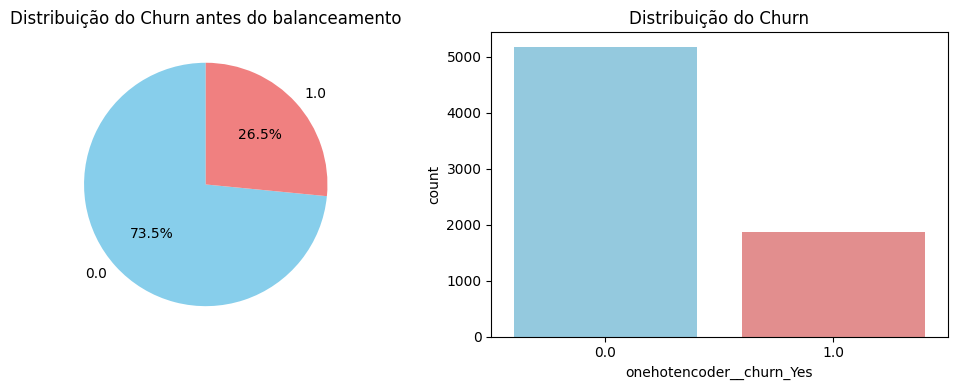

In [27]:
#Plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

#Plot pizza
pie_colors=['skyblue','lightcoral']
axes[0].pie(dados_encoded['onehotencoder__churn_Yes'].value_counts(), labels=dados_encoded['onehotencoder__churn_Yes'].value_counts().index, autopct='%1.1f%%',
            startangle=90, colors=pie_colors)
axes[0].set_title('Distribuição do Churn antes do balanceamento')

#Plot de contagem

countplot_colors = sns.color_palette(pie_colors)
sns.countplot(x='onehotencoder__churn_Yes', hue = 'onehotencoder__churn_Yes',
              data = dados_encoded, palette = countplot_colors, ax=axes[1],
              legend=False)
axes[1].set_title('Distribuição do Churn')

plt.tight_layout()
plt.show()


A análise da distribuição da variável alvo indicou desbalanceamento entre as classes, com maior proporção de clientes que permaneceram. Esse cenário pode induzir o modelo a privilegiar a classe majoritária, comprometendo sua capacidade de identificar corretamente os casos de cancelamento (classe minoritária).



---



##**Separação dos dados entre explicativas(X) e alvo(y)**

Antes de realizar o balanceamento das classes, os dados foram divididos em conjuntos de treino e teste. Essa etapa é necessária para evitar o vazamento de dados, garantindo que o balanceamento seja aplicado apenas no conjunto de treino e que a avaliação do modelo seja feita sobre dados não utilizados no processo de ajuste.

In [28]:
X = dados_encoded.drop('onehotencoder__churn_Yes', axis = 1)
y = dados_encoded[['onehotencoder__churn_Yes']]

X.shape, y.shape

((7043, 40), (7043, 1))

In [29]:
#Dividir dados entre treino e teste
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X,y, test_size=0.2, random_state = 42)

X_treino.shape, X_teste.shape, y_treino.shape, y_teste.shape

((5634, 40), (1409, 40), (5634, 1), (1409, 1))



---



##**Balanceamento de Classes**

Em cenários com desbalanceamento de classes, modelos de classificação tendem a privilegiar a classe majoritária, podendo apresentar elevada acurácia, porém baixo desempenho na identificação da classe minoritária, o evento de interesse neste projeto.

Para mitigar esse viés, optou-se pela aplicação da técnica de oversampling SMOTE, que gera exemplos sintéticos da classe minoritária com base em seus vizinhos mais próximos, promovendo maior equilíbrio na base de treinamento sem simplesmente replicar observações existentes.

In [30]:
from imblearn.over_sampling import SMOTE
#Balancear os dados
sm = SMOTE(random_state=42)
X_treino_balanceado, y_treino_balanceado = sm.fit_resample(X_treino, y_treino)



---



##**Normalização dos dados**

Considerando que o conjunto de dados apresenta variáveis numéricas em diferentes escalas — como tempo de contrato, cobranças mensais e valor total acumulado — optou-se pela normalização dos dados.

A padronização foi necessária para evitar que variáveis com maior magnitude numérica exercessem influência desproporcional no processo de otimização do modelo, especialmente em algoritmos sensíveis à escala, como a Regressão Logística.

Dessa forma, garantiu-se que todas as variáveis contribuíssem de maneira equilibrada para o treinamento do modelo.

In [31]:
from sklearn.preprocessing import StandardScaler


In [32]:
#Normalização

scaler = StandardScaler()
scaler.fit(X_treino_balanceado)

X_treino_norm = scaler.transform(X_treino_balanceado)
X_teste_norm = scaler.transform(X_teste)



---



##**Análise de Correlação**

A análise de correlação foi realizada para identificar o grau de associação entre as variáveis, permitindo detectar possíveis relações relevantes com o churn e verificar a existência de multicolinearidade entre os preditores.

In [34]:
#Correlação
corr = dados_encoded.corr()

In [35]:
#Quais fatores estão mais correlacionados com o churn?

corr['onehotencoder__churn_Yes'].sort_values(ascending=False)

,onehotencoder__churn_Yes
onehotencoder__churn_Yes,1.000000
onehotencoder__account_contract_Month-to-month,0.405103
onehotencoder__internet_online_security_No,0.342637
onehotencoder__internet_tech_support_No,0.337281
onehotencoder__internet_internet_service_Fiber optic,0.308020
onehotencoder__account_payment_method_Electronic check,0.301919
onehotencoder__internet_online_backup_No,0.268005
onehotencoder__internet_device_protection_No,0.252481
remainder__account_charges_monthly,0.193356
onehotencoder__account_paperless_billing_Yes,0.191825


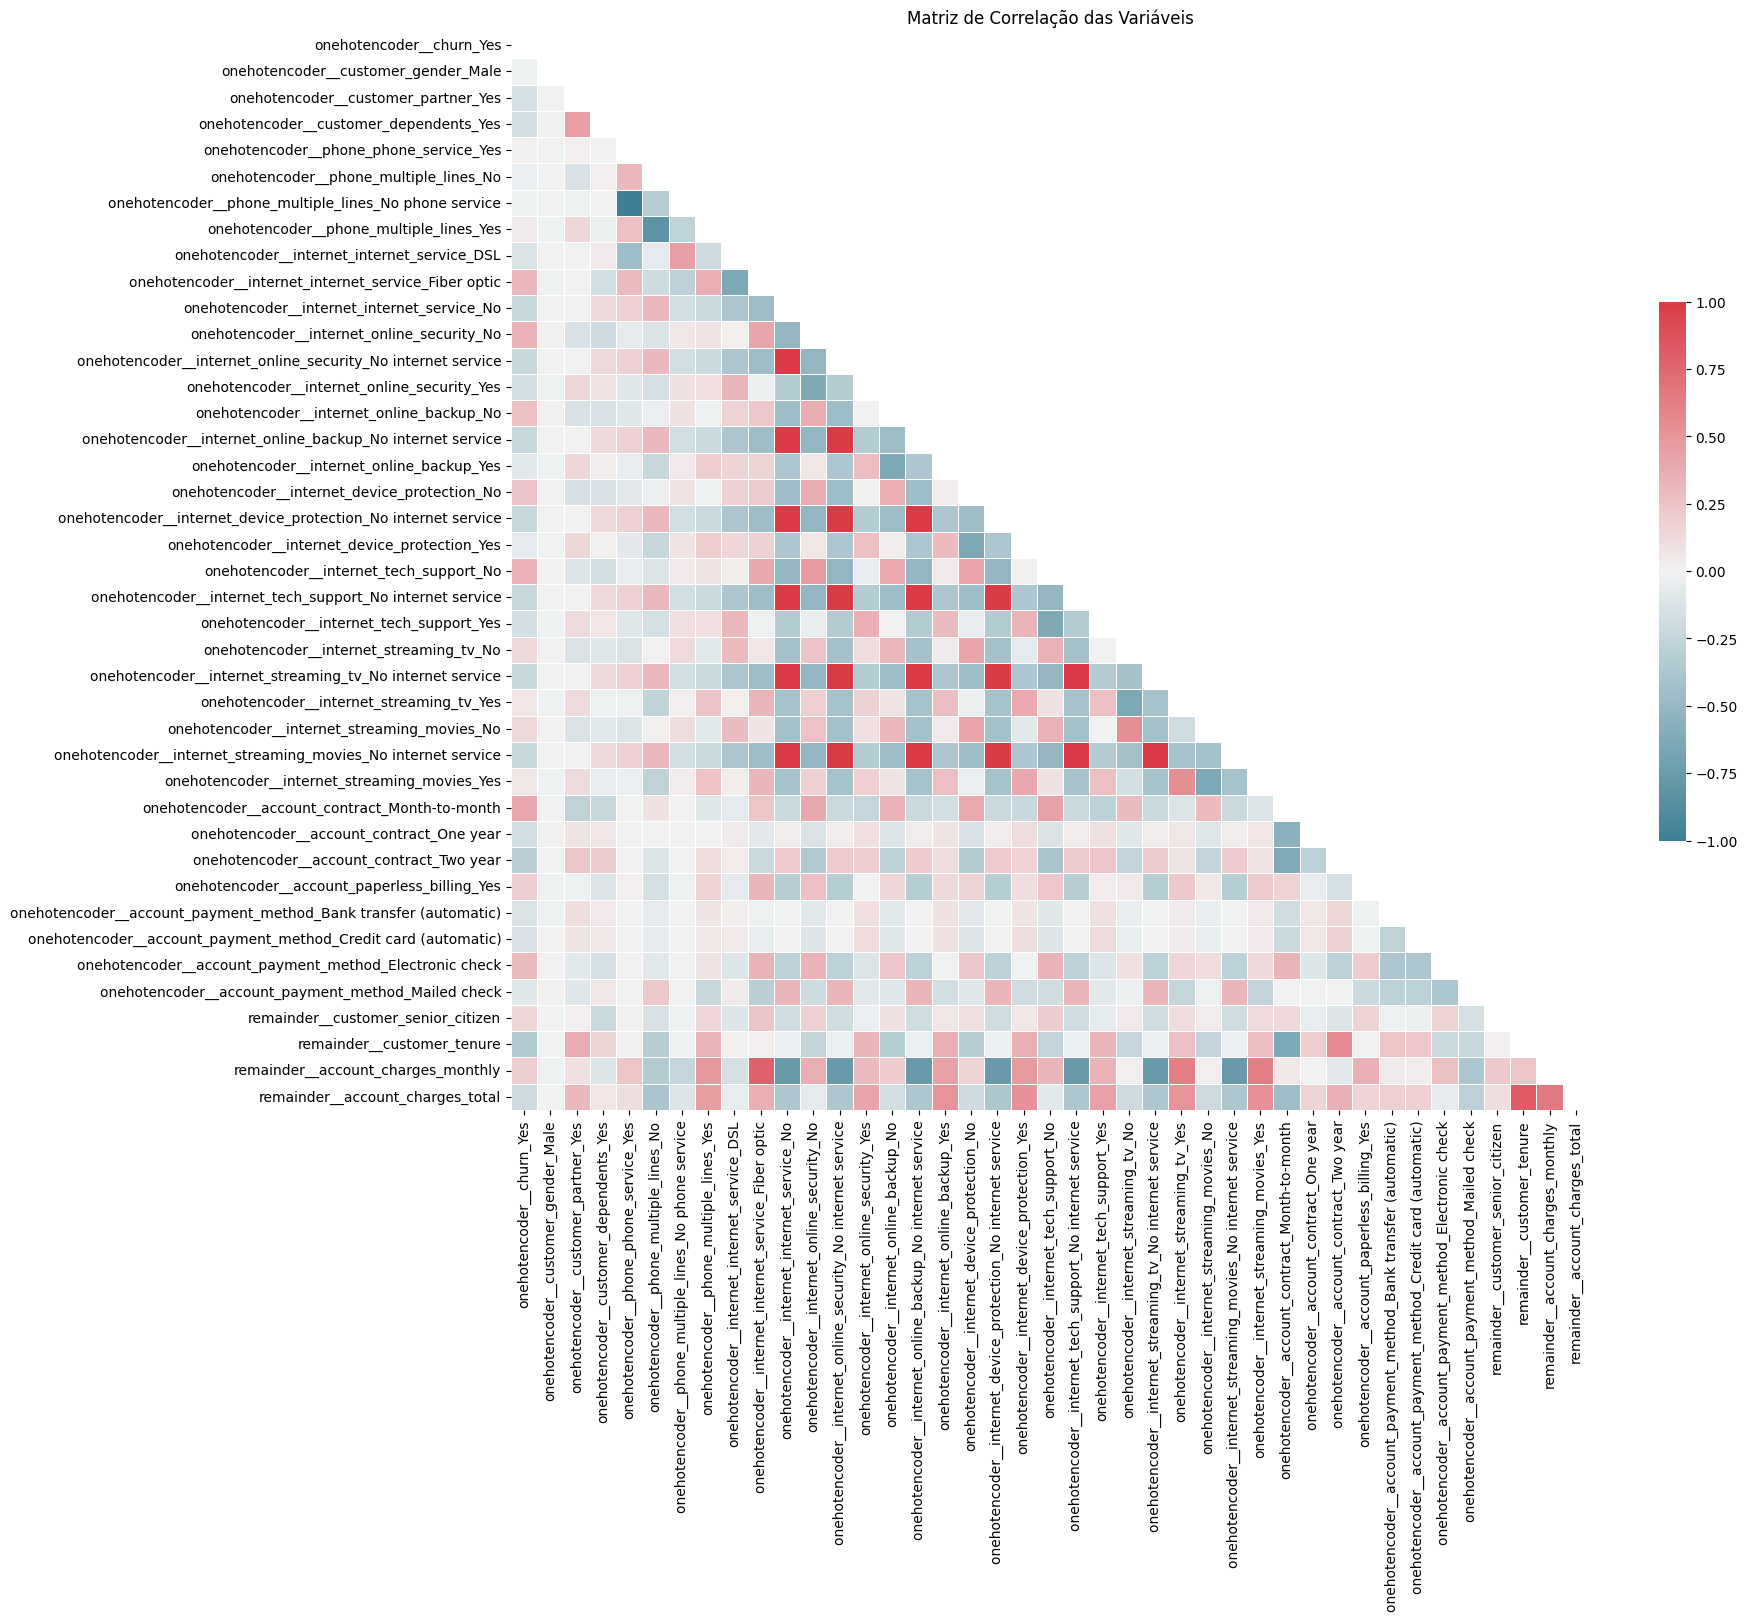

In [36]:
#Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

#Configurar figura do matplotlib
f, ax = plt.subplots(figsize=(18,14))

#Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220,10, as_cmap=True)

sns.heatmap(corr, mask=mascara,cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=False, cbar_kws={'shrink':.5})
plt.title('Matriz de Correlação das Variáveis')
#Exibir o mapa de calor
plt.show()


In [37]:
corr_churn = corr['onehotencoder__churn_Yes']\
                .drop('onehotencoder__churn_Yes')

top3_pos= corr_churn.sort_values(ascending=False).head(3)
top3_pos


,onehotencoder__churn_Yes
onehotencoder__account_contract_Month-to-month,0.405103
onehotencoder__internet_online_security_No,0.342637
onehotencoder__internet_tech_support_No,0.337281


In [38]:
top3_neg = corr_churn.sort_values(ascending=True).head(3)
top3_neg

,onehotencoder__churn_Yes
remainder__customer_tenure,-0.352229
onehotencoder__account_contract_Two year,-0.302253
onehotencoder__internet_internet_service_No,-0.227890




---



### **Análise de Correlação**

A análise de matriz de correlação revelou que contratos mensais e a ausência de serviços adicionais (segurança online e suporte técnico) apresentam associação positiva com a evasão.

Por outro lado, maior tempo de relacionamento e contratos de longo prazo demonstraram correlação negativa, indicando potencial de retenção. Essas variáveis são fortes candidatas para o modelo preditivo.

A seguir, são apresentadas as seis variáveis com maior associação positiva e negativa em relação ao Churn.

In [39]:
top6 = pd.concat([top3_pos, top3_neg])

top6_df = top6.reset_index()
top6_df.columns = 'Variável', 'Correlação com Churn'

top6_df

,Variável,Correlação com Churn
0,onehotencoder__account_contract_Month-to-month,0.405103
1,onehotencoder__internet_online_security_No,0.342637
2,onehotencoder__internet_tech_support_No,0.337281
3,remainder__customer_tenure,-0.352229
4,onehotencoder__account_contract_Two year,-0.302253
5,onehotencoder__internet_internet_service_No,-0.227890




---



##**Análises direcionadas**

Nesta seção, foram investigadas as relações entre as variáveis específicas (Tempo de contrato e Total gasto) com a Evasão, para visualizar padrões e possíveis tendências.

###**Distribuição do tempo de contrato X Churn**

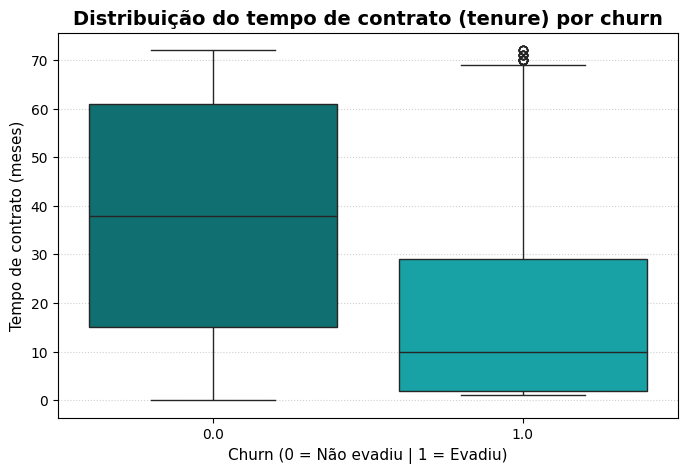

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='onehotencoder__churn_Yes',
    y='remainder__customer_tenure',
    data = dados_encoded,
    hue='onehotencoder__churn_Yes',
    palette=['#007e80', '#00b9bd'],
    legend=False
)

plt.title('Distribuição do tempo de contrato (tenure) por churn', fontsize=14, weight='bold')
plt.xlabel('Churn (0 = Não evadiu | 1 = Evadiu)', fontsize=11)
plt.ylabel('Tempo de contrato (meses)', fontsize=11)

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

Por meio do Boxplot da **Distribuição do tempo de contrato por churn**, observa que os clientes evadiram tendem a ter tempos de contrato menores em comparação aos que permaneceram.

Isso sugere que clientes com contratos mais curtos apresentam maior propensão ao churn, enquanto aqueles com contratos mais longos tendem a permanecer.

###**Distribuição do total de gastos por churn**

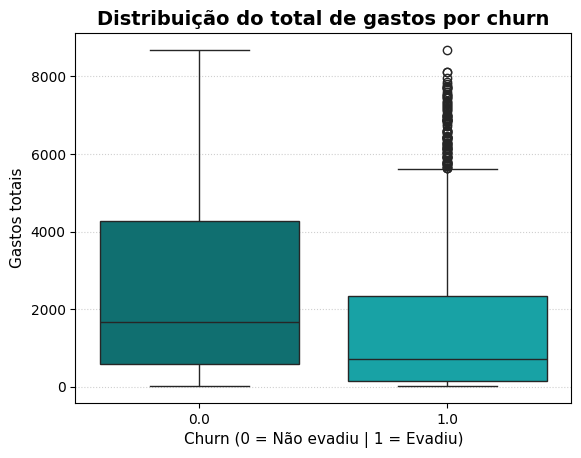

In [41]:
sns.boxplot(x='onehotencoder__churn_Yes',
            y='remainder__account_charges_total',
            data=dados_encoded,
            palette=['#007e80', '#00b9bd'],
            hue ='onehotencoder__churn_Yes',
            legend=False
)


plt.title('Distribuição do total de gastos por churn', fontsize=14, weight='bold')
plt.xlabel('Churn (0 = Não evadiu | 1 = Evadiu)', fontsize=11)
plt.ylabel('Gastos totais', fontsize=11)

plt.grid(axis='y', linestyle=':', alpha=0.6)A p
plt.show()

No Boxplot da **Distribuição de Total de Gastos por Churn**, observa-se que os clientes que evadiram apresentaram um total de gastos menor em comparação aos que permaneceram. A mediana de gastos dos clientes que deixaram a empresa é inferior, indicando que clientes com menor investimento ou consumo tender a ter maior propensão ao churn. Esse padrão sugere que aumentar o engajamento dos clientes com serviços, pode ajudar a reduzir o churn.



---



##**Modelagem preditiva**

Nesta seção damos seguimento à criação de modelos preditivos com o objetivo de identificar clientes com maior probabilidade de evasão (churn).

Serão explorados modelos de Regressão Logística e Random Forest, que posteriormente serão avaliados por métricas adequadas, garantindo a construção de modelos robustos e confiáveis.

###**Regressão Logística**

A Regressão Logística foi adotada por ser adequada a problemas de classificação binária, nos quais a variável dependente assume duas categorias.

No presente caso, o Churn é representado como um evento dicotômico (Sim/Não), o que justifica a escolha do modelo.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [43]:
modelo_regressao_logist = LogisticRegression()

In [44]:
modelo_regressao_logist.fit(X_treino_norm, y_treino_balanceado)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

**Gerando previsões para o teste (X_teste_norm)**

In [45]:
y_previsto = modelo_regressao_logist.predict(X_teste_norm)

**Métricas de avaliação**


In [90]:
print("Treino:")
print(classification_report(y_treino_balanceado, modelo_regressao_logist.predict(X_treino_norm)))

print("Teste:")
print(classification_report(y_teste, modelo_regressao_logist.predict(X_teste_norm)))

Treino:
              precision    recall  f1-score   support

         0.0       0.80      0.73      0.76      4138
         1.0       0.75      0.81      0.78      4138

    accuracy                           0.77      8276
   macro avg       0.77      0.77      0.77      8276
weighted avg       0.77      0.77      0.77      8276

Teste:
              precision    recall  f1-score   support

         0.0       0.91      0.74      0.81      1036
         1.0       0.52      0.79      0.63       373

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [46]:
nomes = ['Churn No', 'Churn Yes']
print('Acurácia Logistic Regression:', round(accuracy_score(y_teste, y_previsto),2))
print(''*20)
print('Matriz de confusão:\n', confusion_matrix(y_teste, y_previsto))
print(''*20)
print('Classification Report: \n', classification_report(y_teste, y_previsto, target_names = nomes))

Acurácia Logistic Regression: 0.75

Matriz de confusão:
 [[763 273]
 [ 77 296]]

Classification Report: 
               precision    recall  f1-score   support

    Churn No       0.91      0.74      0.81      1036
   Churn Yes       0.52      0.79      0.63       373

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



###**Random Forest**

O Random Forest foi selecionado por sua capacidade de modelar relações não lineares e reduzir overfitting por meio da combinação de múltiplas árvores de decisão, sendo adequado para problemas de classificação como a previsão de churn.

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [48]:
modelo_random_forest = RandomForestClassifier(random_state=42)
modelo_random_forest.fit(X_treino_balanceado, y_treino_balanceado)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=42)

**Gerando previsões para o teste (X_teste_norm)**

In [49]:
y_previsto_random_forest = modelo_random_forest.predict(X_teste)

**Métricas de avaliação**

In [93]:
print("Treino - Random Forest:")
print(classification_report(y_treino_balanceado,
                            modelo_random_forest.predict(X_treino_balanceado)))

print("Teste - Random Forest:")
print(classification_report(y_teste,
                            modelo_random_forest.predict(X_teste)))

Treino - Random Forest:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4138
         1.0       1.00      1.00      1.00      4138

    accuracy                           1.00      8276
   macro avg       1.00      1.00      1.00      8276
weighted avg       1.00      1.00      1.00      8276

Teste - Random Forest:
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1036
         1.0       0.63      0.49      0.55       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [50]:
print("Accurácia Random Forest:", round(accuracy_score(y_teste, y_previsto_random_forest),2))
print(''*20)
print('Matriz de Confusão:\n', confusion_matrix(y_teste, y_previsto_random_forest))
print(''*20)
print('Classification Report: \n', classification_report(y_teste, y_previsto_random_forest))

Accurácia Random Forest: 0.79

Matriz de Confusão:
 [[927 109]
 [190 183]]

Classification Report: 
               precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1036
         1.0       0.63      0.49      0.55       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409





---



##**Avaliação dos Modelos**

###**Regressão Logística**

A Regressão Logística apresentou acurácia de 75%. Destaca-se o recall de 0.79 para a classe de churn, indicando elevada capacidade de identificação de clientes que efetivamente cancelaram. Embora a precision e F1-Score da classe minoritária tenham sido moderados(0.52 e 0.63, respectivamente).

A comparação entre métricas de treino e teste indica ausência de overfitting relevante, dado que a acurácia e o recall da classe minoritária apresentam variações pequenas entre os conjuntos.

###**Random Forest**

O modelo Random Forest apresentou acurácia de 79%. Observa-se bom desempenho na identificação de clientes que não cancelam (recall de 0,89). Entretanto, para a classe de churn, o recall foi de 0,49, indicando que aproximadamente metade dos clientes que cancelaram não foram corretamente identificados. O F1-Score nesse caso foi moderado. Assim, embora o modelo apresente desempenho global satisfatório, há limitação na detecção da classe minoritária.

O desempenho perfeito no conjunto de treino, aliado à queda expressiva do F1-score da classe minoritária no teste, caracteriza overfitting, evidenciando perda de capacidade de generalização.

###**Conclusão da análise de modelos**

Embora a Random Forest tenha apresentado acurácia ligeiramente superior, a Regressão Logística demonstrou melhor desempenho na identificação da classe de churn, com recall de 0,79.

Como o principal objetivo do problema é detectar clientes que podem cancelar, a maior sensibilidade da Regressão Logística à classe minoritária a torna mais adequada para estratégias de retenção, mesmo com uma precisão moderada.



---



##**Análise de importância das Variáveis**

In [86]:
pd.Series(
    modelo_regressao_logist.coef_[0],
    index=X_treino_norm.columns
).sort_values(key=abs, ascending=False).head(10)

,0
remainder__customer_tenure,-1.469466
remainder__account_charges_total,0.832210
remainder__account_charges_monthly,-0.601623
onehotencoder__account_contract_Two year,-0.320989
onehotencoder__account_contract_Month-to-month,0.307005
onehotencoder__internet_internet_service_Fiber optic,0.300637
onehotencoder__internet_internet_service_DSL,-0.256440
onehotencoder__account_payment_method_Electronic check,0.159720
onehotencoder__internet_streaming_tv_Yes,0.153981
onehotencoder__internet_streaming_movies_Yes,0.126534


O gráfico abaixo exibe as variáveis com maior impacto no modelo de Regressão Logística para previsão de churn.

Quanto maior a barra, maior a influência da variável na probabilidade estimada de evasão. A variável de maior impacto no modelo foi o tempo de relacionamento, indicando que clientes mais antigos possuem probabilidade menor de churn. Entre os fatores de riscos destacam-se contratos mensais e gastos totais.

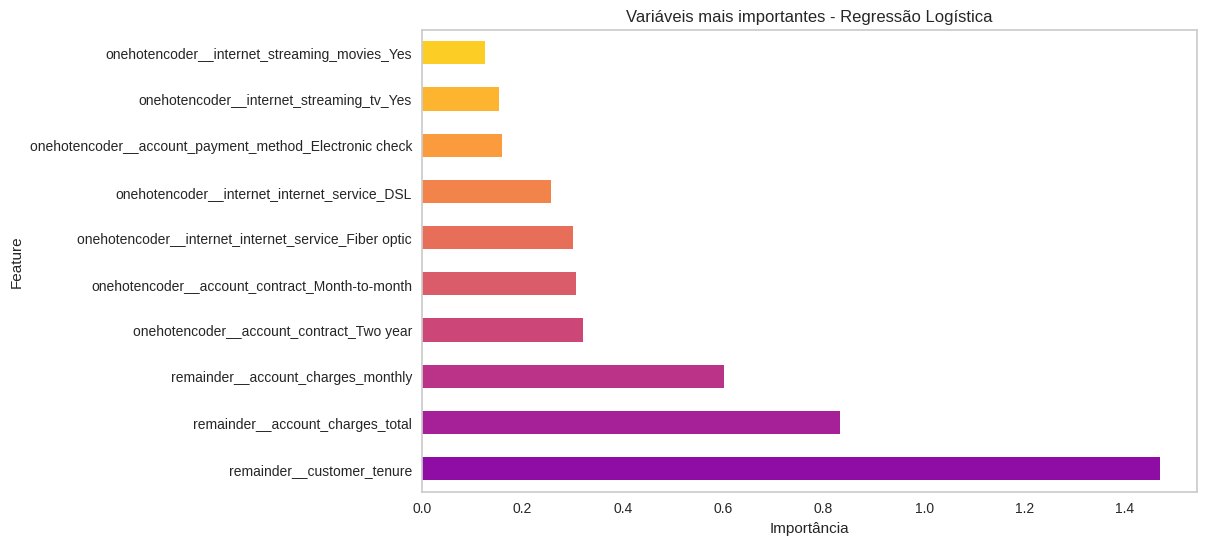

In [101]:
#Variaveis mais importantes modelo Logistic Regression

X_treino_norm = pd.DataFrame(
    X_treino_norm,
    columns=X_treino_balanceado.columns
)

coeficientes = modelo_regressao_logist.coef_[0]
feature_importance = pd.DataFrame({'Feature':X_treino_norm.columns, 'Importance':np.abs(coeficientes)})
feature_importance=feature_importance.sort_values(by='Importance', ascending=False).head(10)

#paleta semelhante yellow brick
colors = plt.cm.plasma(np.linspace(0.3, 0.9, 10))

#gráfico top 10
ax = feature_importance.plot(x='Feature', y='Importance', color=colors, kind='barh', figsize=(10,6), legend=False)
ax.set_xlabel('Importância')
ax.set_title('Variáveis mais importantes - Regressão Logística')
ax.grid(False)
plt.show()



---



#**Conclusão Geral da Análise**

A partir da análise preditiva da evasão de clientes foram extraídas informações relevantes para a compreensão do cancelamento dos serviços da Telecom X.

##**Principais fatores**
O modelo de Regressão Logística foi avaliado como o mais adequado para este projeto, com uma acurácia de 75% e capacidade de identificar 79% dos clientes que de fato evadiram.

Com base nele, os principais fatores que podem impactar na previsão do churn são:
- tempo de contrato
- gastos totais
- gastos mensais

##**Recomendações Estratégicas**

- Desenvolver estratégias voltadas a retenção de clientes que assinam contrato de curto prazos;
- Criar benefícios que nos planos de maior prazo, que façam com que os clientes optem por contratá-los e permanecer consumindo as suas vantagens.
- Utilizar o modelo de Regressão Logística para realizar o monitoramento das variáveis que impactam na previsão do churn e possíveis mudanças nesse cenário.